In [19]:
import numpy as np
import pandas as pd

In [20]:
df = pd.read_csv("2  powerplant_data.csv")
print(df.head())

      AT      V       AP     RH      PE
0   8.34  40.77  1010.84  90.01  480.48
1  23.64  58.49  1011.40  74.20  445.75
2  29.74  56.90  1007.15  41.91  438.76
3  19.07  49.69  1007.22  76.79  453.09
4  11.80  40.66  1017.13  97.20  464.43


AT => temp
V => vaccum
AP => pressure
RH => humidity

PE => produced energy (output)

In [21]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [22]:
X = df.drop(columns="PE", axis=1)
y = df["PE"]

In [23]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test

(         AT      V       AP     RH
 5487  25.24  63.47  1011.30  66.21
 3522  26.09  70.40  1007.41  85.37
 6916  26.63  73.68  1015.15  85.13
 7544  32.06  71.85  1007.90  56.44
 7600  28.70  71.64  1007.11  69.85
 ...     ...    ...      ...    ...
 5734  26.25  61.02  1011.47  71.22
 5191  29.17  64.79  1016.43  61.05
 5390  18.00  43.70  1015.40  61.28
 860   26.73  68.84  1010.75  66.83
 7270   6.40  39.18  1024.60  86.83
 
 [7654 rows x 4 columns],
          AT      V       AP     RH
 2513  29.70  57.35  1005.63  57.35
 9411  25.71  71.64  1008.85  77.31
 8745  17.83  44.92  1025.04  70.58
 9085   9.46  41.40  1026.78  87.58
 4950  29.90  64.79  1016.90  48.24
 ...     ...    ...      ...    ...
 7204  20.46  51.43  1010.06  83.79
 1599  29.70  67.17  1007.31  66.56
 5697  14.64  39.58  1011.46  71.90
 350   29.47  71.32  1008.07  67.00
 6210  17.70  50.88  1015.44  89.57
 
 [1914 rows x 4 columns])

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
import torch
import torch.nn as nn

In [28]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

X_train_tensor, y_test_tensor

(tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
         [ 0.8618,  1.2652, -0.9852,  0.8182],
         [ 0.9341,  1.5231,  0.3252,  0.8017],
         ...,
         [-0.2210, -0.8350,  0.3676, -0.8355],
         [ 0.9475,  1.1425, -0.4197, -0.4546],
         [-1.7736, -1.1905,  1.9252,  0.9184]]),
 tensor([[433.2700],
         [438.1600],
         [458.4200],
         ...,
         [467.8000],
         [437.1400],
         [456.7800]]))

In [29]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [30]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

Deep Learning

In [31]:
#Define ANN model...
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()

    self.model = nn.Sequential(

        #1st hidden layer
        nn.Linear(X_train.shape[1], 6),
        nn.ReLU(),

        #2nd hidden layer
        nn.Linear(6, 6),
        nn.ReLU(),

        #output layer
        nn.Linear(6, 1)
    )

  def forward(self, x):
    return self.model(x)

In [32]:
import torch.optim as optim

model = ANN()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [33]:
# Train the ANN
best_val_loss = float("inf")

train_losses = []
valid_losses = []

epochs = 20
for epoch in range(epochs):
  model.train()
  running_loss = 0.0 # total training loss for 1 batch

  # training loop for single batch
  for xb, yb in train_loader:
    # xb = feautures of 1 batch
    # yb = lables of 1 batch

    optimizer.zero_grad() # doesnt include past gradients

    outputs = model(xb) # forward prop
    loss = criterion(outputs, yb) # compute loss (predicted, actual)
    loss.backward() # back prop.. compute gradients
    optimizer.step() #params update
    running_loss += loss.item() # loss is a tensor => py float

  epoch_train_loss = running_loss / len(train_loader)
  train_losses.append(epoch_train_loss)

  # Vaidation
  running_val_loss = 0.0

  with torch.no_grad():
    for xb, yb in test_loader:
      outputs = model(xb)
      loss = criterion(outputs, yb)
      running_val_loss += loss.item()

  epoch_val_loss = running_val_loss / len(test_loader)
  valid_losses.append(epoch_val_loss)

  print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

# --- Save best model ---
  if epoch_val_loss < best_val_loss:
      best_val_loss = epoch_val_loss
      torch.save(model.state_dict(), "best_model.pth")
      print(f"Saved best model at epoch {epoch+1} with val loss {epoch_val_loss:.4f}")


epoch 1/20 ==> train loss = 206557.04186197917 & val loss = 205007.33098958334
Saved best model at epoch 1 with val loss 205007.3310
epoch 2/20 ==> train loss = 199580.744921875 & val loss = 189999.46171875
Saved best model at epoch 2 with val loss 189999.4617
epoch 3/20 ==> train loss = 170466.29518229168 & val loss = 145053.784375
Saved best model at epoch 3 with val loss 145053.7844
epoch 4/20 ==> train loss = 114607.58369140625 & val loss = 83996.51510416667
Saved best model at epoch 4 with val loss 83996.5151
epoch 5/20 ==> train loss = 59801.3814453125 & val loss = 40184.25478515625
Saved best model at epoch 5 with val loss 40184.2548
epoch 6/20 ==> train loss = 29663.900451660156 & val loss = 22137.364664713543
Saved best model at epoch 6 with val loss 22137.3647
epoch 7/20 ==> train loss = 18624.514154052733 & val loss = 15648.074934895832
Saved best model at epoch 7 with val loss 15648.0749
epoch 8/20 ==> train loss = 13992.747123209636 & val loss = 12114.392366536458
Saved be

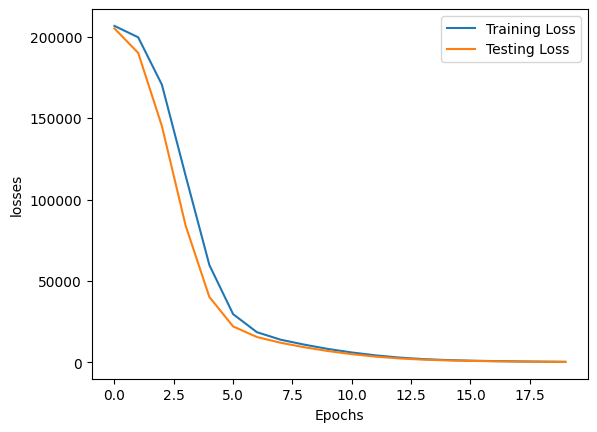

In [34]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Testing Loss" : valid_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Testing Loss"], label = "Testing Loss")

plt.xlabel("Epochs")
plt.ylabel("losses")

plt.legend()
plt.show()

Load Model

In [43]:
#load model

#Define ANN model...
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()

    self.model = nn.Sequential(

        #1st hidden layer
        nn.Linear(X_train.shape[1], 6),
        nn.ReLU(),

        #2nd hidden layer
        nn.Linear(6, 6),
        nn.ReLU(),

        #output layer
        nn.Linear(6, 1)
    )

  def forward(self, x):
    return self.model(x)

model = ANN()
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

with torch.no_grad():
  preds = model(X_test_tensor)

print(preds[:2])

tensor([[437.9172],
        [427.9133]])


In [41]:
# Evaluation : isme hum directly training data tensors, testing data tensors ku predict karinge

model.eval()
with torch.no_grad():
  train_preds = model(X_train_tensor)
  test_preds = model(X_test_tensor)

  train_mse = criterion(train_preds, y_train_tensor)
  test_mse = criterion(test_preds, y_test_tensor)

print("Training MSE : ", train_mse.item())
print("Testing MSE : ", test_mse.item())

from sklearn.metrics import r2_score
print("r^2 score = ", r2_score(y_test, test_preds))

Training MSE :  355.9460754394531
Testing MSE :  348.7286376953125
r^2 score =  -0.21871680858994158


In [42]:
#just to see
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,437.917236,433.27
1,427.913300,438.16
2,470.020966,458.42
3,500.288544,480.82
4,438.467377,441.41
...,...,...
1909,445.209259,456.70
1910,446.158813,438.04
1911,458.847687,467.80
1912,449.713531,437.14
